In [2]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
from pandas import Period
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [4]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_price", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN", "FR_rt_ren_processed.csv")


In [5]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [6]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
all_data = add_cyclical_features(all_data)


In [7]:
import numpy as np
import pandas as pd

def create_sliding_window_numpy(
        df,
        target_col="EUR/MWh",
        window_days=7,
        forecast_horizon=1,
        rt_cols=["EUR/MWh", "Load_DA", "Solar_DA", "Wind_DA"],
        rt_cyc_cols=["sin_hour", "cos_hour", "sin_day", "cos_day", "sin_month", "cos_month"],
    ):

    df = df.sort_values("Date").reset_index(drop=True)
    hours = 24
    window_size = window_days * hours
    n = len(df)

    # ---- Storage ----
    X_rt_list = []
    X_rt_cyc_list = []
    y_list = []
    y1_list = []
    y7_list = []
    dates = []

    for i in range(window_size, n - forecast_horizon):

        dates.append(df.loc[i, "Date"])

        # =========================================
        # 1️⃣  REAL-TIME WINDOW   (unchanged)
        # =========================================
        rt_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                    for col in rt_cols]
        X_rt_list.append(np.stack(rt_stack, axis=1))

        rt_cyc_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                        for col in rt_cyc_cols]
        X_rt_cyc_list.append(np.stack(rt_cyc_stack, axis=1))



        # =========================================
        # 3️⃣  TARGETS (H-hour vector)
        # =========================================
        y_list.append(
            df.loc[i:i+forecast_horizon-1, target_col].values.astype(float)
        )

        y1_list.append(
            df.loc[i-hours:i-hours+forecast_horizon-1, target_col].values.astype(float)
        )

        y7_list.append(
            df.loc[i-7*hours:i-7*hours+forecast_horizon-1, target_col].values.astype(float)
        )

    # ----------- Convert to numpy arrays --------------
    X_rt       = np.array(X_rt_list)       # (N, window, n_rt)
    X_rt_cyc   = np.array(X_rt_cyc_list)   # (N, window, n_rt_cyc)

    y          = np.array(y_list)          # (N, H)
    y_1d       = np.array(y1_list)         # (N, H)
    y_7d       = np.array(y7_list)         # (N, H)
    dates      = np.array(dates)

    # ---- Merge RT windows ----
    X_rt_full = np.concatenate([X_rt, X_rt_cyc], axis=2)  # (N, window, n_rt+n_rt_cyc)



    # =====================================
    # FEATURE MAP (for normalization)
    # =====================================
    feature_map = {
        "rt_cols": rt_cols,
        "rt_cyc_cols": rt_cyc_cols,
        "rt_window_features": {
            "start_idx": 0,
            "end_idx": len(rt_cols)-1
        },
        "rt_cyclic_features": {
            "start_idx": len(rt_cols),
            "end_idx": len(rt_cols)+len(rt_cyc_cols)-1
        },

        "forecast_horizon": forecast_horizon
    }

    return X_rt_full, y, y_1d, y_7d, dates, feature_map


In [8]:
X_rt, y, y_1d, y_7d, dates, feature_map = create_sliding_window_numpy(all_data,
                                                                            target_col="EUR/MWh",
                                                                            window_days=7,
                                                                            forecast_horizon=1)

In [9]:
print("Shapes")
print("X_rt:", X_rt.shape)
print("y:", y.shape)
print("y_1d:", y_1d.shape)
print("y_7d:", y_7d.shape)

Shapes
X_rt: (51978, 168, 10)
y: (51978, 1)
y_1d: (51978, 1)
y_7d: (51978, 1)


In [10]:
def month_based_split_np(
        X_rt,
        y,
        y_1d,
        y_7d,
        dates,
        features_map,
        train_ratio=0.6,
        dev_ratio=0.2,
        seed=42
    ):
    """
    Month-based split for NumPy-array datasets.
    """

    # --- Convert dates to pandas for easy month extraction ---
    dates_pd = pd.to_datetime(dates)
    yearmonth = dates_pd.to_period("M")

    # --- Unique months ---
    all_months = np.array(yearmonth.unique())
    n_months = len(all_months)

    # --- Shuffle months ---
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(all_months)

    # --- Split ---
    n_train = int(train_ratio * n_months)
    n_dev   = int(dev_ratio * n_months)

    train_m = shuffled[:n_train]
    dev_m   = shuffled[n_train : n_train+n_dev]
    test_m  = shuffled[n_train+n_dev :]

    # --- Boolean masks on rows ---
    mask_train = yearmonth.isin(train_m)
    mask_dev   = yearmonth.isin(dev_m)
    mask_test  = yearmonth.isin(test_m)

    # --- Helper to index all arrays ---
    def select(mask):
        return (
            X_rt[mask],
            y[mask],
            y_1d[mask],
            y_7d[mask],
            dates[mask]
        )

    Xrt_tr, y_tr, y1d_tr, y7d_tr, d_tr = select(mask_train)
    Xrt_de, y_de, y1d_de, y7d_de, d_de = select(mask_dev)
    Xrt_te, y_te, y1d_te, y7d_te, d_te = select(mask_test)

    return {
        "train": (Xrt_tr, y_tr, y1d_tr, y7d_tr, d_tr),
        "dev":   (Xrt_de, y_de, y1d_de, y7d_de, d_de),
        "test":  (Xrt_te, y_te, y1d_te, y7d_te, d_te),
        "months": {
            "train": train_m,
            "dev": dev_m,
            "test": test_m
        },
        "feature_map": features_map
    }


In [11]:
splits = month_based_split_np(
    X_rt, y, y_1d, y_7d, dates, feature_map
)
Xrt_train, y_train, y1d_train, y7d_train, dates_train = splits["train"]
Xrt_dev,   y_dev,   y1d_dev,   y7d_dev,   dates_dev   = splits["dev"]
Xrt_test,  y_test,  y1d_test,  y7d_test,  dates_test  = splits["test"]

features_map = splits["feature_map"]


In [12]:

df_price  = all_data[["Time","EUR/MWh"]]

df_rt_load = all_data[["Time","Load_DA"]]
df_rt_ren  = all_data[["Time","Solar_DA","Wind_DA"]]
for df in [df_price, df_rt_load, df_rt_ren]:
    df["Date"] = pd.to_datetime(df["Time"], utc=True)
    df["YearMonth"] = df["Date"].dt.to_period("M")
train_months = splits["months"]["train"]  # <-- from your earlier split

df_price_tr  = df_price[df_price["YearMonth"].isin(train_months)]
df_rt_load_tr = df_rt_load[df_rt_load["YearMonth"].isin(train_months)]
df_rt_ren_tr  = df_rt_ren[df_rt_ren["YearMonth"].isin(train_months)]

stats_dict = {}

def compute_stats(df, cols, container, prefix=""):
    for c in cols:
        arr = df[c].astype(float).values
        container[prefix + c] = {
            "mean": float(np.nanmean(arr)),
            "std":  float(np.nanstd(arr) + 1e-8)
        }

# --- price y ---
compute_stats(df_price_tr, ["EUR/MWh"], stats_dict, prefix="price_")

# --- RT features ---
rt_cols = ["Load_DA", "Solar_DA", "Wind_DA"]
compute_stats(df_rt_load_tr.merge(df_rt_ren_tr, on="Date"), rt_cols, stats_dict, prefix="rt_")




/tmp/ipykernel_7204/606519030.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Time"], utc=True)
/tmp/ipykernel_7204/606519030.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["Date"].dt.to_period("M")
/tmp/ipykernel_7204/606519030.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["YearMonth"] = df["Date"].dt.to_period("M")
/tmp/ipykernel_7204/606519030.py:6: SettingWithCopyWarning: 
A value is tr

In [13]:
def normalize_sets(
    Xrt, y,
    stats_dict,
    feature_map
):
    """
    Normalizes:
      - y using price stats
      - Xrt windowed features (EUR/MWh, Load_RT, Solar_RT, Wind_RT)
      - Xrt cyclic features untouched
      - Xda DA features
      - Xda cyclic features untouched
    """

    # --- Copies ---
    Xrt = Xrt.copy()
    y   = y.copy()

    # -----------------------
    # Normalize y
    # -----------------------
    y_mean = stats_dict["price_EUR/MWh"]["mean"]
    y_std  = stats_dict["price_EUR/MWh"]["std"]
    y = (y - y_mean) / y_std

    # -----------------------
    # Normalize Xrt
    # -----------------------
    rt_cols = feature_map["rt_cols"]
    rt_cyc_cols = feature_map["rt_cyc_cols"]
    start_rt = feature_map["rt_window_features"]["start_idx"]
    end_rt   = feature_map["rt_window_features"]["end_idx"]

    # Windowed RT features (first 4 columns)
    for j, feat in enumerate(rt_cols):
        if feat == "EUR/MWh":
            mean, std = y_mean, y_std
        else:
            mean = stats_dict[f"rt_{feat}"]["mean"]
            std  = stats_dict[f"rt_{feat}"]["std"]

        Xrt[:, :, start_rt + j] = (Xrt[:, :, start_rt + j] - mean) / std

    # Cyclic RT: do nothing

    # Cyclic DA: untouched

    return Xrt, y


In [14]:
Xrt_train_norm, y_train_norm = normalize_sets(
    Xrt_train, y_train,
    stats_dict,
    feature_map
)

Xrt_dev_norm, y_dev_norm = normalize_sets(
    Xrt_dev, y_dev,
    stats_dict,
    feature_map
)

Xrt_test_norm, y_test_norm = normalize_sets(
    Xrt_test, y_test,
    stats_dict,
    feature_map
)

# #Keep prices only (First channel)
# Xrt_train_norm = Xrt_train_norm[:, :, 0:1]
# Xrt_dev_norm = Xrt_dev_norm[:, :, 0:1]
# Xrt_test_norm = Xrt_test_norm[:, :, 0:1]

# # Keep other features only
# Xrt_train_norm = Xrt_train_norm[:, :, 1:]
# Xrt_dev_norm = Xrt_dev_norm[:, :, 1:]
# Xrt_test_norm = Xrt_test_norm[:, :, 1:]

In [15]:
Xrt_train_norm = Xrt_train_norm.reshape(Xrt_train_norm.shape[0], -1)
Xrt_dev_norm = Xrt_dev_norm.reshape(Xrt_dev_norm.shape[0], -1)
Xrt_test_norm = Xrt_test_norm.reshape(Xrt_test_norm.shape[0], -1)
print("Shapes after normalization:")
print("Xrt_train_norm:", Xrt_train_norm.shape)
print("y_train_norm:", y_train_norm.shape)

Shapes after normalization:
Xrt_train_norm: (31023, 1680)
y_train_norm: (31023, 1)


In [16]:


class MLP(nn.Module):
    def __init__(
        self,
        input_dim,           # e.g., 1680
        layers,              # ex: [128, 64, 32]
        dropout=0.0,
        use_batchnorm=False,
        leaky_alpha=0.1
    ):
        super().__init__()

        modules = []
        prev = input_dim

        # Hidden layers
        for h in layers:
            modules.append(nn.Linear(prev, h))
            if use_batchnorm:
                modules.append(nn.BatchNorm1d(h))
            modules.append(nn.LeakyReLU(leaky_alpha))
            if dropout > 0:
                modules.append(nn.Dropout(dropout))
            prev = h

        # Output layer → 1 target
        modules.append(nn.Linear(prev, 1))

        self.net = nn.Sequential(*modules)

    def forward(self, x):
        return self.net(x)


In [ ]:


class SimpleLinear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(in_features=input_dim, out_features=1)

    def forward(self, x):
        return self.linear(x)


In [ ]:
def run_full_train(
    X_seq_train, y_train,
    X_seq_dev,  y_dev,
    layers=[128, 64],      # NEW: Dynamic layer list
    dropout=0.2,
    use_batchnorm=True,
    leaky_alpha=0.1,
    learning_rate=1e-3,
    weight_decay=0.0,
    l1_lambda=0.0,
    batch_size=128,
    epochs=20,
    verbose_freq=1,
    device=device
):
    import torch
    from torch.utils.data import TensorDataset, DataLoader

    # ---------------------------------------
    # Flatten inputs automatically
    # ---------------------------------------
    input_dim=X_seq_train.shape[1]


    # ---------------------------------------
    # Convert numpy → torch
    # ---------------------------------------
    X_train_t = torch.as_tensor(X_seq_train, dtype=torch.float32)
    y_train_t = torch.as_tensor(y_train,      dtype=torch.float32).view(-1, 1)

    X_dev_t   = torch.as_tensor(X_seq_dev,   dtype=torch.float32)
    y_dev_t   = torch.as_tensor(y_dev,        dtype=torch.float32).view(-1, 1)

    train_ds = TensorDataset(X_train_t, y_train_t)
    dev_ds   = TensorDataset(X_dev_t,   y_dev_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_ds,   batch_size=batch_size, shuffle=False)

    # ---------------------------------------
    # Build flexible MLP
    # ---------------------------------------
    if layers == "linear":
        model = SimpleLinear(input_dim=input_dim).to(device)
    else:
        model = MLP(
            input_dim=input_dim,
            layers=layers,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            leaky_alpha=leaky_alpha
        ).to(device)
    # ---------------------------------------
    # Optimizer + Scheduler
    # ---------------------------------------
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=learning_rate * 0.1
    )

    mae_loss = torch.nn.L1Loss()

    print("Model:")
    print(model)
    print(f"Batch size: {batch_size} | Epochs: {epochs}")

    train_hist = []
    val_hist   = []

    # Pre-cache params for L1 regularization
    l1_params = [p for p in model.parameters() if p.dim() > 1]

    for epoch in range(1, epochs + 1):

        # -------------------------
        # Train
        # -------------------------
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = mae_loss(preds, yb)

            # L1 penalty (optional)
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in l1_params)
                loss += l1_lambda * l1_penalty

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_mae = running_loss / len(train_loader)
        train_hist.append(train_mae)

        # -------------------------
        # Validation
        # -------------------------
        model.eval()
        val_loss_total = 0.0

        with torch.no_grad():
            for xb, yb in dev_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                preds = model(xb)
                val_loss_total += mae_loss(preds, yb).item() * xb.size(0)

        val_mae = val_loss_total / len(dev_ds)
        val_hist.append(val_mae)

        scheduler.step()

        # -------------------------
        # Logging
        # -------------------------
        if (epoch - 1) % verbose_freq == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(
                f"Epoch {epoch:03d} | Train MAE: {train_mae:.6f} "
                f"| Val MAE: {val_mae:.6f} | LR: {lr_now:.3e}"
            )

    return model, train_hist, val_hist


In [18]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [89]:
# -----------------------------------------
# Experiment config
# -----------------------------------------
all_exp_params_dnn = {
    "baseline_dnn": {
        "layers": [1024,512,128,64,32],   
        "dropout": 0,
        "use_batchnorm": False,
        "leaky_alpha": 0.05164602613665692,
        "learning_rate": 0.00046588614349230386,
        "weight_decay": 2.298009246731028e-05,
        "l1_lambda": 5e-5,
        "batch_size": 256,
        "epochs": 40
    }
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

# -----------------------------------------
# Run experiments
# -----------------------------------------
for tag, params in all_exp_params_dnn.items():
    print("=" * 70)
    print(f"Running experiment: {tag}")
    print("=" * 70)

    baseline_dnn, train_hist, val_hist = run_full_train(
        Xrt_train_norm, y_train_norm,
        Xrt_dev_norm,   y_dev_norm,
        layers=params["layers"],          # <── NEW
        dropout=params["dropout"],
        use_batchnorm=params["use_batchnorm"],
        leaky_alpha=params["leaky_alpha"],
        learning_rate=params["learning_rate"],
        weight_decay=params["weight_decay"],
        l1_lambda=params.get("l1_lambda", 0.0),
        batch_size=params["batch_size"],
        epochs=params["epochs"],
        verbose_freq=1
    )
    exp_results[tag] = {
        "train_loss": train_hist,
        "val_loss": val_hist,
    }

# -----------------------------------------
# Save results
# -----------------------------------------
save_object_to_file(exp_results, results_save_path)

# Reload (to confirm)
exp_results = read_object_from_file(results_save_path)

# -----------------------------------------
# Plot all results
# -----------------------------------------
for tag, r in exp_results.items():
    train_loss = r["train_loss"]
    val_loss   = r["val_loss"]

    plt.figure(figsize=(7, 5))
    plt.plot(train_loss, label="Train MAE")
    plt.plot(val_loss, label="Validation MAE")
    plt.title(f"{tag} – MAE vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{tag}{plot_suffix}")
    plt.close()

plt.show()


Running experiment: baseline_dnn
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=1680, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.05164602613665692)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.05164602613665692)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): LeakyReLU(negative_slope=0.05164602613665692)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): LeakyReLU(negative_slope=0.05164602613665692)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): LeakyReLU(negative_slope=0.05164602613665692)
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)
Batch size: 256 | Epochs: 40
Epoch 001 | Train MAE: 0.833565 | Val MAE: 0.166559 | LR: 4.652e-04
Epoch 002 | Train MAE: 0.289056 | Val MAE: 0.170927 | LR: 4.633e-04
Epoch 003 | Train MAE: 0.217833 | Val MAE: 0.155596 | LR: 4.601e-04
Epoch 004 | Train MAE: 0.184615 | Val MAE: 0.14227

In [103]:

# -----------------------------------------
# Experiment config
# -----------------------------------------
all_exp_params = {    "linear_baseline": {
        "layers": "linear",
        "dropout": 0.0,
        "use_batchnorm": False,
        "leaky_alpha": 0.0,
        "learning_rate": 0.046588614349230386,
        "weight_decay": 0.0,
        "l1_lambda": 0.0, 
        "batch_size": 256,
        "epochs": 200,
    }

}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

# -----------------------------------------
# Run experiments
# -----------------------------------------
for tag, params in all_exp_params.items():
    print("=" * 70)
    print(f"Running experiment: {tag}")
    print("=" * 70)

    baseline_linear, train_hist, val_hist = run_full_train(
        Xrt_train_norm, y_train_norm,
        Xrt_dev_norm,   y_dev_norm,
        layers=params["layers"],          # <── NEW
        dropout=params["dropout"],
        use_batchnorm=params["use_batchnorm"],
        leaky_alpha=params["leaky_alpha"],
        learning_rate=params["learning_rate"],
        weight_decay=params["weight_decay"],
        l1_lambda=params.get("l1_lambda", 0.0),
        batch_size=params["batch_size"],
        epochs=params["epochs"],
        verbose_freq=1
    )
    exp_results[tag] = {
        "train_loss": train_hist,
        "val_loss": val_hist,
    }

# -----------------------------------------
# Save results
# -----------------------------------------
save_object_to_file(exp_results, results_save_path)

# Reload (to confirm)
exp_results = read_object_from_file(results_save_path)

# -----------------------------------------
# Plot all results
# -----------------------------------------
for tag, r in exp_results.items():
    train_loss = r["train_loss"]
    val_loss   = r["val_loss"]

    plt.figure(figsize=(7, 5))
    plt.plot(train_loss, label="Train MAE")
    plt.plot(val_loss, label="Validation MAE")
    plt.title(f"{tag} – MAE vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{tag}{plot_suffix}")
    plt.close()

plt.show()


Running experiment: linear_baseline
Model:
SimpleLinear(
  (linear): Linear(in_features=1680, out_features=1, bias=True)
)
Batch size: 256 | Epochs: 200
Epoch 001 | Train MAE: 2.153115 | Val MAE: 1.853043 | LR: 4.659e-02
Epoch 002 | Train MAE: 1.396363 | Val MAE: 1.265117 | LR: 4.658e-02
Epoch 003 | Train MAE: 1.234916 | Val MAE: 1.511366 | LR: 4.657e-02
Epoch 004 | Train MAE: 1.240012 | Val MAE: 1.389671 | LR: 4.655e-02
Epoch 005 | Train MAE: 1.425576 | Val MAE: 1.835056 | LR: 4.652e-02
Epoch 006 | Train MAE: 1.478602 | Val MAE: 1.250313 | LR: 4.650e-02
Epoch 007 | Train MAE: 1.145080 | Val MAE: 1.046848 | LR: 4.646e-02
Epoch 008 | Train MAE: 1.231209 | Val MAE: 2.071278 | LR: 4.642e-02
Epoch 009 | Train MAE: 1.215144 | Val MAE: 1.507218 | LR: 4.638e-02
Epoch 010 | Train MAE: 1.116381 | Val MAE: 1.356304 | LR: 4.633e-02
Epoch 011 | Train MAE: 1.289412 | Val MAE: 1.473651 | LR: 4.628e-02
Epoch 012 | Train MAE: 1.282702 | Val MAE: 1.360175 | LR: 4.622e-02
Epoch 013 | Train MAE: 1.294638

In [93]:
def evaluate_model(
    model,
    X_seq_np,
    y_np,
    y_np_1d,
    y_np_7d,
    stats_dict,
    batch_size,
    device="cpu"
):
    """
    Evaluation for MULTI-STEP forecasting (e.g. H=24).
    y_np must be shape (N, H)
    model outputs (N, H)
    """

    # ----------------------
    # Get normalization stats
    # ----------------------
    mean_FR = stats_dict["price_EUR/MWh"]["mean"]
    std_FR  = stats_dict["price_EUR/MWh"]["std"]

    model = model.to(device).eval()

    N = len(X_seq_np)
    preds_list = []

    # ----------------------
    # Predict
    # ----------------------
    with torch.no_grad():
        for i in range(0, N, batch_size):

            xb_seq = torch.from_numpy(X_seq_np[i:i+batch_size]).float().to(device)

            out = model(xb_seq)
            preds_list.append(out.cpu().numpy())

    predictions = np.concatenate(preds_list, axis=0)  # (N, H)

    # ----------------------
    # Denormalize
    # ----------------------
    predictions = predictions * std_FR + mean_FR
    y_np        = y_np        * std_FR + mean_FR

    # ----------------------
    # Metrics (multi-step)
    # ----------------------

    # MAE averaged over all 24 steps
    mae = np.mean(np.abs(predictions - y_np))

    # Median baseline (per horizon)
    median_val = np.median(y_np, axis=0)          # shape (H,)
    mae_median = np.mean(np.abs(median_val - y_np))
    maem = mae / mae_median

    # rMAE using naive (t-24)
    mae_model_1d = mae
    mae_naive_1d = np.mean(np.abs(y_np_1d - y_np))   # y_np_1d is (N,H)
    rMAE_1d = mae_model_1d / mae_naive_1d

    # rMAE using naive (t-168)
    mae_model_7d = mae
    mae_naive_7d = np.mean(np.abs(y_np_7d - y_np))
    rMAE_7d = mae_model_7d / mae_naive_7d



    print(f"MAE: {mae:.4f} | MAEm: {maem:.4f} | rMAE-1d: {rMAE_1d:.4f} | rMAE-7d: {rMAE_7d:.4f}" )

    return {
        "predictions": predictions,
        "MAE": mae,
        "MAEm": maem,
        "rMAE_1d": rMAE_1d,
        "rMAE_7d": rMAE_7d
    }



In [94]:
print("Evaluating the baseline DNN model:")
print("Evaluating on test set:")
eval_res_test_dnn = evaluate_model(baseline_dnn, Xrt_test_norm, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=all_exp_params_dnn["baseline_dnn"]["batch_size"], device=device)
print("Evaluating on the dev set:")
eval_res_dev_dnn = evaluate_model(baseline_dnn, Xrt_dev_norm, y_dev_norm, y1d_dev, y7d_dev, stats_dict, batch_size=all_exp_params_dnn["baseline_dnn"]["batch_size"], device=device)
print("Evaluating on train set:")
eval_res_train_dnn = evaluate_model(baseline_dnn, Xrt_train_norm, y_train_norm, y1d_train, y7d_train, stats_dict, batch_size=all_exp_params_dnn["baseline_dnn"]["batch_size"], device=device)

Evaluating the baseline DNN model:
Evaluating on test set:
MAE: 7.7480 | MAEm: 0.1388 | rMAE-1d: 0.3497 | rMAE-7d: 0.2524
Evaluating on the dev set:
MAE: 8.4565 | MAEm: 0.0949 | rMAE-1d: 0.3504 | rMAE-7d: 0.2215
Evaluating on train set:
MAE: 6.6192 | MAEm: 0.0970 | rMAE-1d: 0.2974 | rMAE-7d: 0.2136


In [104]:
print("Evaluating the baseline linear model:")
print("Evaluating on test set:")
eval_res_test_linear = evaluate_model(baseline_linear, Xrt_test_norm, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=all_exp_params["linear_baseline"]["batch_size"], device=device)
print("Evaluating on the dev set:")
eval_res_dev_linear = evaluate_model(baseline_linear, Xrt_dev_norm, y_dev_norm, y1d_dev, y7d_dev, stats_dict, batch_size=all_exp_params["linear_baseline"]["batch_size"], device=device)
print("Evaluating on train set:")
eval_res_train_linear = evaluate_model(baseline_linear, Xrt_train_norm, y_train_norm, y1d_train, y7d_train, stats_dict, batch_size=all_exp_params["linear_baseline"]["batch_size"], device=device)

Evaluating the baseline linear model:
Evaluating on test set:
MAE: 17.8745 | MAEm: 0.3202 | rMAE-1d: 0.8068 | rMAE-7d: 0.5823
Evaluating on the dev set:
MAE: 20.2489 | MAEm: 0.2273 | rMAE-1d: 0.8389 | rMAE-7d: 0.5304
Evaluating on train set:
MAE: 19.0963 | MAEm: 0.2798 | rMAE-1d: 0.8580 | rMAE-7d: 0.6162


In [105]:
hours_train = np.arange(eval_res_train_dnn["predictions"].shape[0]) % 24
hours_dev   = np.arange(eval_res_dev_dnn["predictions"].shape[0]) % 24
hours_test  = np.arange(eval_res_test_dnn["predictions"].shape[0]) % 24


In [106]:
def per_hour_metrics(preds, y,y1d,y7d, hours):
    preds = preds.squeeze()
    y = y.squeeze()
    med=np.median(y)
    mae = np.zeros(24)
    maem=np.zeros(24)
    rmae1 = np.zeros(24)
    rmae7 = np.zeros(24)
    for h in range(24):
        mask = (hours == h)
        mae[h] = np.mean(np.abs(preds[mask] - y[mask]))
        maem[h] = mae[h]/np.mean(np.abs(preds[mask] - med))
        rmae1[h] = mae[h]/np.mean(np.abs(preds[mask] - y1d[mask]))
        rmae7[h] = mae[h]/np.mean(np.abs(preds[mask] - y7d[mask]))
    return mae, maem, rmae1, rmae7


In [107]:
#Per-hour prediction on the train/dev/test
mae_test_hour_dnn,maem_test_hour_dnn,rmae1_test_hour_dnn,rmae7_test_hour_dnn  = per_hour_metrics(eval_res_test_dnn["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)
mae_test_hour_linear,maem_test_hour_linear,rmae1_test_hour_linear,rmae7_test_hour_linear  = per_hour_metrics(eval_res_test_linear["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)



In [109]:
#save predictions to .pkl file
preds=eval_res_test_dnn["predictions"]
save_object_to_file(preds, "predictions_dnn.pkl")
preds=eval_res_test_linear["predictions"]
save_object_to_file(preds, "predictions_linear.pkl")

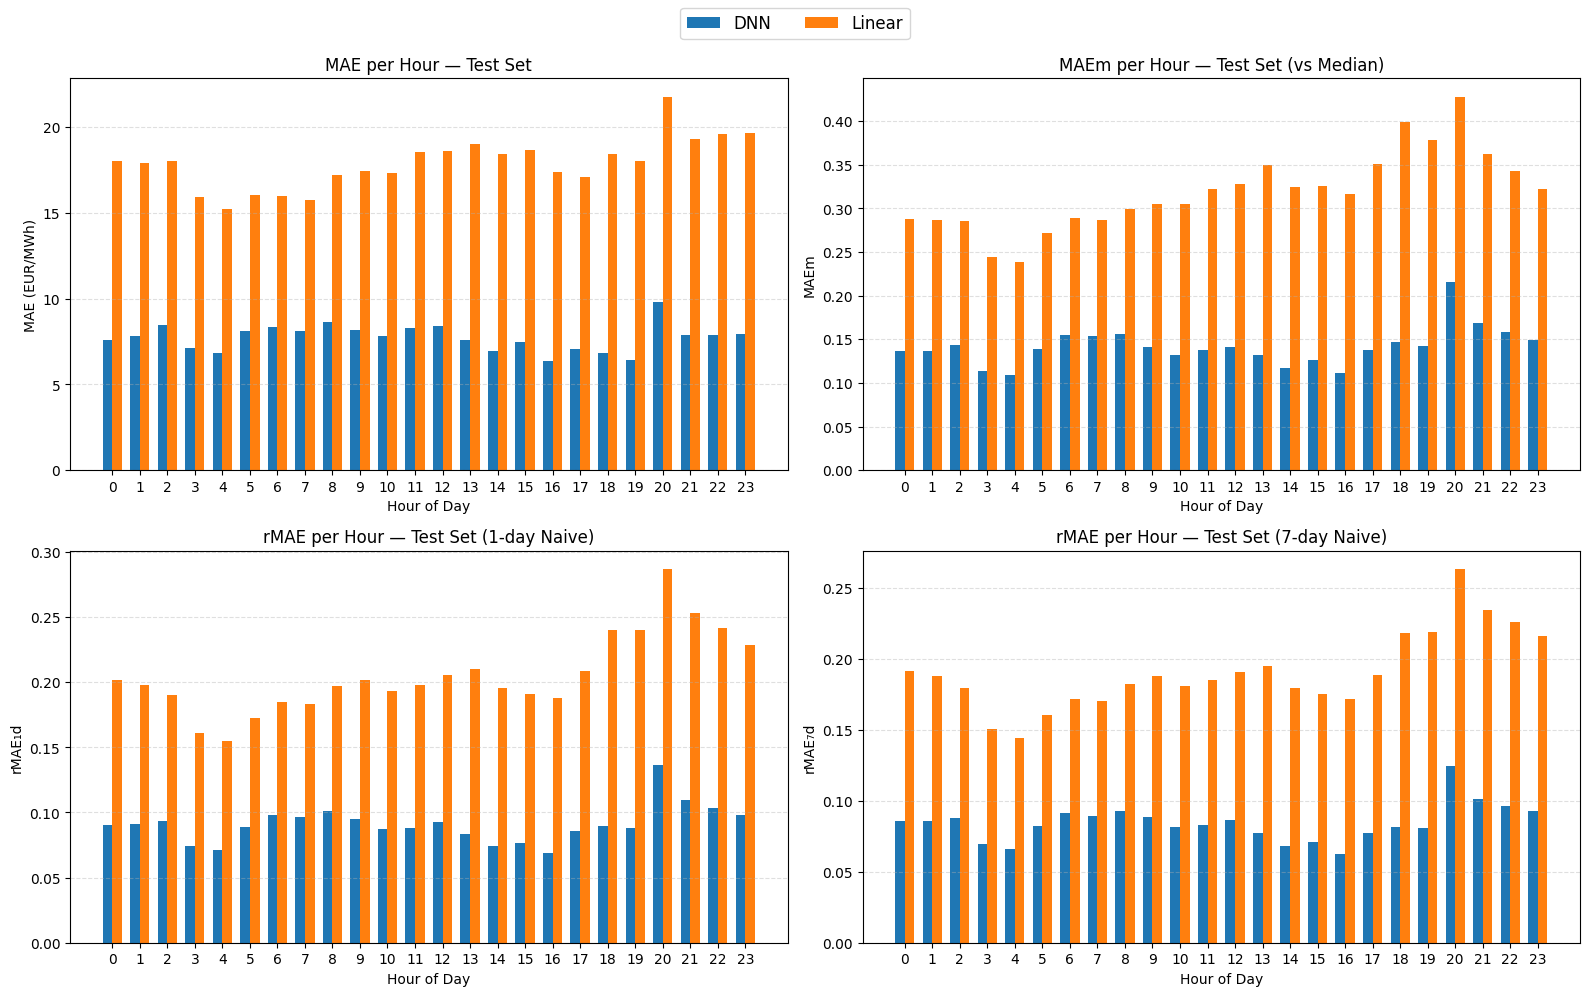

In [108]:
hours = np.arange(24)
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Colors
color_dnn    = '#1f77b4'
color_linear = '#ff7f0e'

# -------------------------------------
# 1) MAE per hour
# -------------------------------------
ax = axes[0, 0]
ax.bar(hours - width/2, mae_test_hour_dnn,    width, label="DNN",    color=color_dnn)
ax.bar(hours + width/2, mae_test_hour_linear, width, label="Linear", color=color_linear)
ax.set_title("MAE per Hour — Test Set")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# 2) MAEm per hour
# -------------------------------------
ax = axes[0, 1]
ax.bar(hours - width/2, maem_test_hour_dnn,    width, label="DNN",    color=color_dnn)
ax.bar(hours + width/2, maem_test_hour_linear, width, label="Linear", color=color_linear)
ax.set_title("MAEm per Hour — Test Set (vs Median)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MAEm")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# 3) rMAE 1-day per hour
# -------------------------------------
ax = axes[1, 0]
ax.bar(hours - width/2, rmae1_test_hour_dnn,    width, label="DNN",    color=color_dnn)
ax.bar(hours + width/2, rmae1_test_hour_linear, width, label="Linear", color=color_linear)
ax.set_title("rMAE per Hour — Test Set (1-day Naive)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("rMAE₁d")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# 4) rMAE 7-day per hour
# -------------------------------------
ax = axes[1, 1]
ax.bar(hours - width/2, rmae7_test_hour_dnn,    width, label="DNN",    color=color_dnn)
ax.bar(hours + width/2, rmae7_test_hour_linear, width, label="Linear", color=color_linear)
ax.set_title("rMAE per Hour — Test Set (7-day Naive)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("rMAE₇d")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# Formatting
# -------------------------------------
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
#Plot on the training set
plt.figure(figsize=(12,6))
idx=np.random.randint(0, len(eval_res_train["predictions"])-24)
plt.plot(y_train[idx:idx+24], label="True Prices")
plt.plot(eval_res_train["predictions"][idx:idx+24], label="Predicted Prices")
plt.title("Training Set: True vs Predicted Prices (sample index {})".format(idx))
plt.xlabel("Sample Index")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.show()

In [ ]:
# -----------------------------
# Hyperparameter Tuning (clean)
# -----------------------------

results = {}   # store all results

dropout_values = np.linspace(0.0, 0.5, num=5)
architectures = [(64,1), (64,2), (128,1), (128,2)]

for d in dropout_values:
    for a in architectures:

        hidden_units, layers = a

        print("="*60)
        print(f"Training with dropout={d:.3f}  | hidden={hidden_units}  | layers={layers}")
        print("="*60)

        model, train_hist, val_hist = run_full_train(
            Xrt_train_norm, y_train_norm,      # training data
            Xrt_dev_norm,   y_dev_norm,        # dev data
            hidden_size = hidden_units,
            num_layers   = layers,
            dropout      = d,
            use_batchnorm = False,
            leaky_alpha   = 0,
            learning_rate = 0.001,
            weight_decay  = 0,
            l1_lambda     = 0,
            batch_size    = params["batch_size"],
            epochs        = 20,
            verbose_freq  = 10
        )

        print("Evaluating on dev set...")
        eval_res_dev = evaluate_model(
            model,
            Xrt_dev_norm,
            y_dev_norm,
            y1d_dev,
            y7d_dev,
            stats_dict,
            batch_size=params["batch_size"],
            device=device
        )

        # store clean results
        results[(d, a)] = {
            "MAE"   : eval_res_dev["MAE"],
            "MAEm"  : eval_res_dev["MAEm"],
            "rMAE1" : eval_res_dev["rMAE_1d"],
            "rMAE7" : eval_res_dev["rMAE_7d"],
        }

# -----------------------------
# Extract best configurations
# -----------------------------
min_mae   = min(v["MAE"]   for v in results.values())
min_maem  = min(v["MAEm"]  for v in results.values())
min_rmae1 = min(v["rMAE1"] for v in results.values())
min_rmae7 = min(v["rMAE7"] for v in results.values())

best_configs_mae   = [k for k,v in results.items() if v["MAE"]   == min_mae]
best_configs_maem  = [k for k,v in results.items() if v["MAEm"]  == min_maem]
best_configs_rmae1 = [k for k,v in results.items() if v["rMAE1"] == min_rmae1]
best_configs_rmae7 = [k for k,v in results.items() if v["rMAE7"] == min_rmae7]

print("\n=========== BEST CONFIGURATIONS ===========")
print(f"Best MAE ({min_mae:.4f}):            {best_configs_mae}")
print(f"Best MAEm ({min_maem:.4f}):          {best_configs_maem}")
print(f"Best rMAE-1d ({min_rmae1:.4f}):       {best_configs_rmae1}")
print(f"Best rMAE-7d ({min_rmae7:.4f}):       {best_configs_rmae7}")
print("==========================================\n")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------------------------------------------------
# 1. Extract axes: architectures and dropouts
# ----------------------------------------------------
# keys are (dropout, (hidden, layers))

archs = sorted({arch for (_, arch) in results.keys()},
               key=lambda x: (x[0], x[1]))   # sorted by hidden, layers

drops = sorted({d for (d, _) in results.keys()})   # sorted dropout values

metric_keys = ["MAE", "MAEm", "rMAE1", "rMAE7"]

# ----------------------------------------------------
# 2. Allocate grid for metrics and cell text
# ----------------------------------------------------
grid = {mk: np.full((len(archs), len(drops)), np.nan, dtype=float)
        for mk in metric_keys}

cell_text = [["" for _ in drops] for _ in archs]

# ----------------------------------------------------
# 3. Fill the matrices
# ----------------------------------------------------
for (d, arch), ev in results.items():
    i = archs.index(arch)
    j = drops.index(d)

    # Fill matrices
    for mk in metric_keys:
        grid[mk][i, j] = ev[mk]

    # Build cell text
    cell_text[i][j] = "\n".join(f"{mk}: {ev[mk]:.4f}" for mk in metric_keys)

# ----------------------------------------------------
# 4. Compute minima of each metric
# ----------------------------------------------------
min_positions = {}

for mk in metric_keys:
    mat = grid[mk]

    if np.isnan(mat).all():
        min_positions[mk] = []
        continue

    min_val = np.nanmin(mat)
    rows, cols = np.where(np.isclose(mat, min_val, atol=1e-12))
    min_positions[mk] = list(zip(rows, cols))

# ----------------------------------------------------
# 5. Plotting full grid
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 6 + 0.6 * len(archs)))

ax.set_xlim(-0.5, len(drops) - 0.5)
ax.set_ylim(len(archs) - 0.5, -0.5)

# ticks
ax.set_xticks(range(len(drops)))
ax.set_xticklabels([f"{d:.2f}" for d in drops], fontsize=14)

ax.set_yticks(range(len(archs)))
ax.set_yticklabels([str(a) for a in archs], fontsize=14)

ax.set_xlabel("Dropout", fontsize=16)
ax.set_ylabel("Architecture (hidden_size, num_layers)", fontsize=16)

# grid lines
for x in range(len(drops) + 1):
    ax.axvline(x - 0.5, color="lightgray", linewidth=0.8)
for y in range(len(archs) + 1):
    ax.axhline(y - 0.5, color="lightgray", linewidth=0.8)

# metric colors
colors = ["red", "blue", "green", "purple"]
metric_colors = {metric_keys[i]: colors[i] for i in range(len(metric_keys))}

legend_patches = [
    patches.Patch(color=metric_colors[mk], label=mk) for mk in metric_keys
]

# cell annotation offsets
y_offsets = [-0.35, -0.12, 0.12, 0.35]

# ----------------------------------------------------
# 6. Annotate cells
# ----------------------------------------------------
for i in range(len(archs)):
    for j in range(len(drops)):
        lines = cell_text[i][j].split("\n")

        for k, mk in enumerate(metric_keys):
            line = lines[k] if k < len(lines) else ""
            color = metric_colors[mk] if (i, j) in min_positions[mk] else "black"

            ax.text(j, i + y_offsets[k],
                    line,
                    ha="center", va="center",
                    fontsize=13,
                    color=color)

# legend
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [20]:
def objective(trial):

    # ====== Search space for MLP layers ======
    n_layers = trial.suggest_int("n_layers", 1, 4)
    
    layer_sizes = []
    for i in range(n_layers):
        size = trial.suggest_categorical(f"layer_{i}_size", [32, 64, 128, 256])
        layer_sizes.append(size)

    # ====== Other hyperparameters ======
    dropout       = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha   = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    l1_lambda     = trial.suggest_float("l1_lambda", 1e-7, 1e-3, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs        = 20

    # ====== Train model ======
    model, train_hist, val_hist = run_full_train(
        Xrt_train_norm, y_train_norm,
        Xrt_dev_norm,   y_dev_norm,
        layers=layer_sizes,          # <── NEW AND IMPORTANT
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        epochs=epochs,
        verbose_freq=5,
        device=device
    )

    # ====== Evaluate model ======
    metrics = evaluate_model(
        model,
        Xrt_dev_norm,
        y_dev_norm,
        y1d_dev,
        y7d_dev,
        stats_dict,
        batch_size=batch_size,
        device=device
    )

    return (
        metrics["MAE"],
        metrics["MAEm"],
        metrics["rMAE_1d"],
        metrics["rMAE_7d"],
    )



# --- Run the multi-objective study ---
study = optuna.create_study(
    directions=["minimize", "minimize", "minimize", "minimize"],
    study_name="FR_LMP_LSTM_TUNING"
)

study.optimize(objective, n_trials=20)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.\n")

for t in best_trials:
    print("Values:", t.values)
    print("Params:", t.params)
    print("-" * 60)


[I 2025-12-01 22:29:10,243] A new study created in memory with name: FR_LMP_LSTM_TUNING


Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=1680, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.16686352368553828)
    (3): Dropout(p=0.0028984438408454216, inplace=False)
    (4): Linear(in_features=64, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.16686352368553828)
    (7): Dropout(p=0.0028984438408454216, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.16686352368553828)
    (11): Dropout(p=0.0028984438408454216, inplace=False)
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(n

[I 2025-12-01 22:29:27,007] Trial 0 finished with values: [9.91402602135531, 0.11130037242677998, 0.4107400233645907, 0.2596709736942638] and parameters: {'n_layers': 4, 'layer_0_size': 64, 'layer_1_size': 256, 'layer_2_size': 256, 'layer_3_size': 256, 'dropout': 0.0028984438408454216, 'use_batchnorm': True, 'leaky_alpha': 0.16686352368553828, 'learning_rate': 0.002481173298977435, 'weight_decay': 1.405840698848602e-06, 'l1_lambda': 2.225030845163182e-05, 'batch_size': 256}.


MAE: 9.9140 | MAEm: 0.1113 | rMAE-1d: 0.4107 | rMAE-7d: 0.2597
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=1680, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.16168655568779972)
    (3): Dropout(p=0.13045325143954817, inplace=False)
    (4): Linear(in_features=32, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.16168655568779972)
    (7): Dropout(p=0.13045325143954817, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.16168655568779972)
    (11): Dropout(p=0.13045325143954817, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=T

[I 2025-12-01 22:29:50,505] Trial 1 finished with values: [16.654962572140892, 0.18697787690292442, 0.6900183337507868, 0.43623149047959797] and parameters: {'n_layers': 4, 'layer_0_size': 32, 'layer_1_size': 256, 'layer_2_size': 64, 'layer_3_size': 32, 'dropout': 0.13045325143954817, 'use_batchnorm': True, 'leaky_alpha': 0.16168655568779972, 'learning_rate': 8.431529337394103e-05, 'weight_decay': 0.00010643595888113623, 'l1_lambda': 4.385122257801386e-06, 'batch_size': 128}.


...

MAE: 9.6425 | MAEm: 0.1083 | rMAE-1d: 0.3995 | rMAE-7d: 0.2526
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=1680, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.047870477523835)
    (3): Dropout(p=0.4092115281314318, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.047870477523835)
    (7): Dropout(p=0.4092115281314318, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Batch size: 64 | Epochs: 20
Epoch 001 | Train MAE: 3.450238 | Val MAE: 0.218247 | LR: 3.735e-05
Epoch 006 | Train MAE: 1.385755 | Val MAE: 0.161745 | LR: 3.059e-05
Epoch 011 | Train MAE: 0.667713 | Val MAE: 0.139678 | LR: 1.801e-05
Epoch 016 | Train MAE: 0.509109 | Val MAE: 0.146664 | LR: 6.984e-06


[I 2025-12-01 22:36:04,282] Trial 18 finished with values: [14.208960546655574, 0.15951769717303935, 0.5886799948223268, 0.3721651135861183] and parameters: {'n_layers': 2, 'layer_0_size': 256, 'layer_1_size': 64, 'dropout': 0.4092115281314318, 'use_batchnorm': True, 'leaky_alpha': 0.047870477523835, 'learning_rate': 3.756210270843949e-05, 'weight_decay': 3.5218128986462164e-05, 'l1_lambda': 0.000562028142727389, 'batch_size': 64}.


MAE: 14.2090 | MAEm: 0.1595 | rMAE-1d: 0.5887 | rMAE-7d: 0.3722
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=1680, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1260167171621199)
    (3): Dropout(p=0.13993442698049408, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1260167171621199)
    (7): Dropout(p=0.13993442698049408, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1260167171621199)
    (11): Dropout(p=0.13993442698049408, inplace=False)
    (12): Linear(in_features=64, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affin

[I 2025-12-01 22:36:20,196] Trial 19 finished with values: [12.090975564137532, 0.13574001928105023, 0.5009314656847781, 0.3166902518603567] and parameters: {'n_layers': 4, 'layer_0_size': 256, 'layer_1_size': 256, 'layer_2_size': 64, 'layer_3_size': 128, 'dropout': 0.13993442698049408, 'use_batchnorm': True, 'leaky_alpha': 0.1260167171621199, 'learning_rate': 0.0004094952527696629, 'weight_decay': 2.854398239152257e-06, 'l1_lambda': 7.18139650213013e-07, 'batch_size': 256}.


MAE: 12.0910 | MAEm: 0.1357 | rMAE-1d: 0.5009 | rMAE-7d: 0.3167
Found 1 Pareto-optimal trials.

Values: [9.549370318611244, 0.10720654460793637, 0.39563226678391417, 0.2501198083865725]
Params: {'n_layers': 1, 'layer_0_size': 64, 'dropout': 0.45099909610831257, 'use_batchnorm': True, 'leaky_alpha': 0.05164602613665692, 'learning_rate': 0.00046588614349230386, 'weight_decay': 2.298009246731028e-05, 'l1_lambda': 0.0007313180937789534, 'batch_size': 256}
------------------------------------------------------------
